In [38]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [39]:
IMAGE_DIR = "Citypersons/images/train/aachen"
NUM_IMAGES = 2
IMG_SIZE = 640
# random.seed(42)

In [40]:
all_images = [
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)
    if f.endswith(".png")
]

sample_images = random.sample(all_images, NUM_IMAGES)
sample_images

['Citypersons/images/train/aachen/aachen_000038_000019_leftImg8bit.png',
 'Citypersons/images/train/aachen/aachen_000109_000019_leftImg8bit.png']

In [41]:
IMG_SIZE = 640
NUM_IMAGES = len(sample_images)  # already selected earlier

# ---------------- PREPROCESS STEPS ----------------
def resize_img(img):
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

def random_zoom(img, zoom_factor=1.15):
    h, w = img.shape[:2]
    nh, nw = int(h / zoom_factor), int(w / zoom_factor)
    y1 = (h - nh) // 2
    x1 = (w - nw) // 2
    crop = img[y1:y1+nh, x1:x1+nw]
    return cv2.resize(crop, (w, h))

def random_rotation(img, angle_range=5):
    angle = random.uniform(-angle_range, angle_range)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def horizontal_flip(img):
    return cv2.flip(img, 1)

def color_normalize(img):
    img = img.astype(np.float32) / 255.0
    return (img * 255).astype(np.uint8)


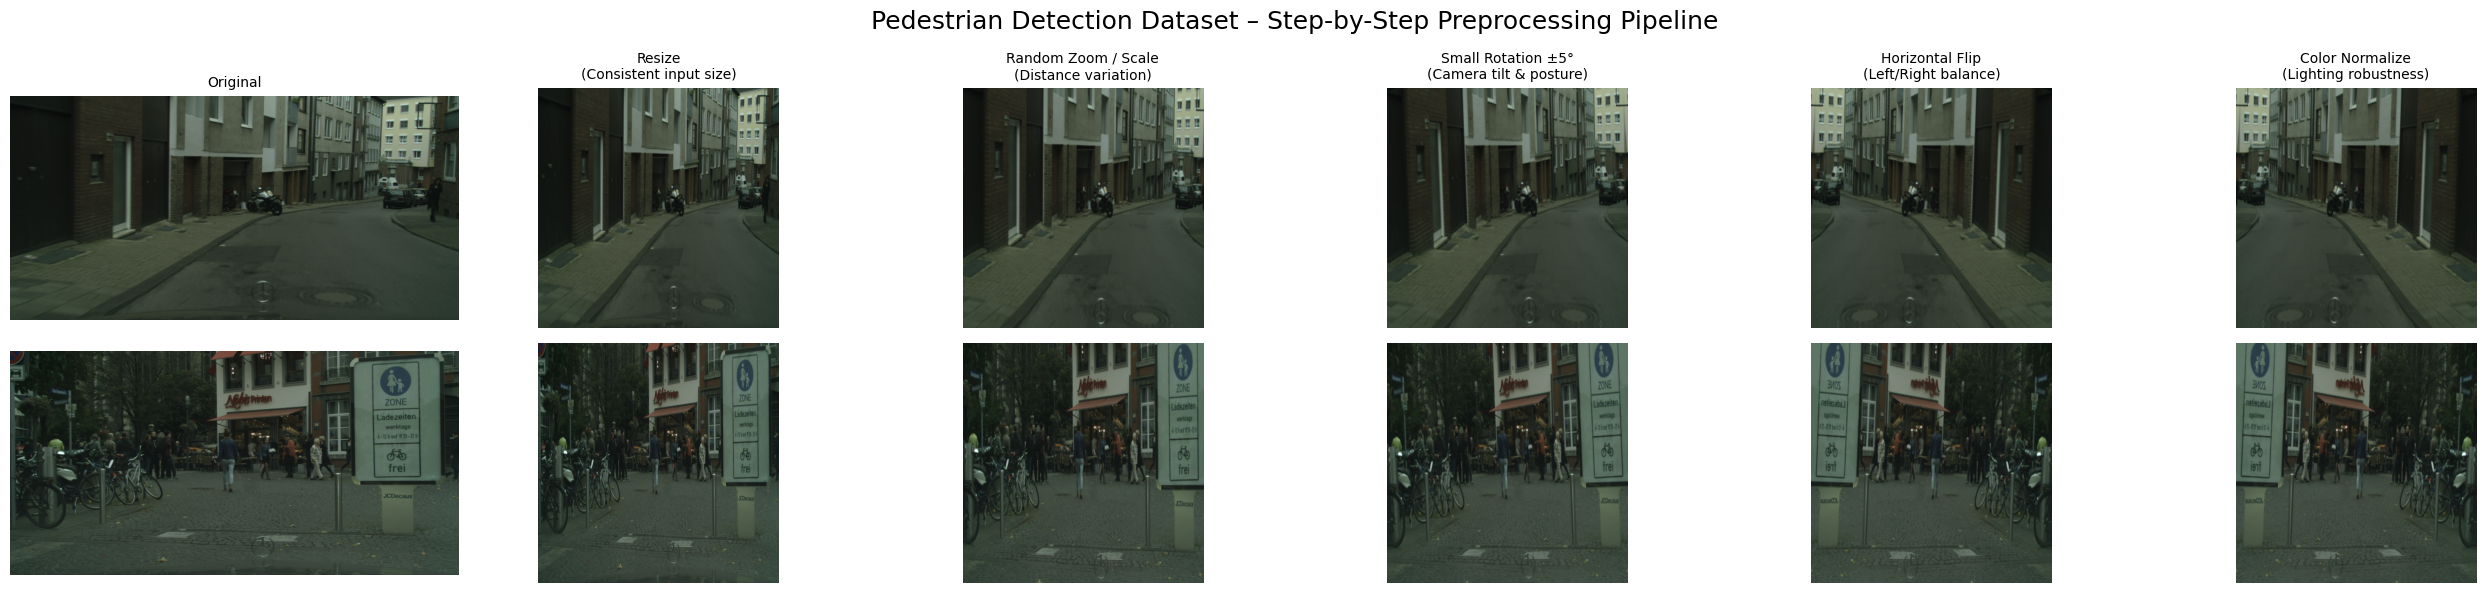

In [42]:
COLS = 6
fig, axes = plt.subplots(NUM_IMAGES, COLS, figsize=(26, 3 * NUM_IMAGES))

titles = [
    "Original",
    "Resize\n(Consistent input size)",
    "Random Zoom / Scale\n(Distance variation)",
    "Small Rotation ±5°\n(Camera tilt & posture)",
    "Horizontal Flip\n(Left/Right balance)",
    "Color Normalize\n(Lighting robustness)"
]

for i, img_path in enumerate(sample_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized = resize_img(img)
    zoomed = random_zoom(resized)
    rotated = random_rotation(zoomed)
    flipped = horizontal_flip(rotated)
    normalized = color_normalize(flipped)

    imgs = [img, resized, zoomed, rotated, flipped, normalized]

    for j in range(COLS):
        axes[i, j].imshow(imgs[j])
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=10)

plt.suptitle(
    "Pedestrian Detection Dataset – Step-by-Step Preprocessing Pipeline",
    fontsize=18
)
plt.tight_layout()
plt.show()